# Multivariate Gaussian Distribution

## Learning Objectives

By the end of this notebook, you should be able to:

- explain why multivariate distributions are needed,
- represent a random vector using a mean vector and covariance matrix,
- interpret variance, covariance, and correlation,
- understand the geometry of a covariance matrix,
- evaluate the multivariate Gaussian probability density function,
- sample from independent and correlated Gaussian distributions,
- generate correlated samples using the Cholesky decomposition,
- connect the multivariate Gaussian to robotics and probabilistic inference.

This notebook focuses on **representation**. Later, we will use these ideas for inference in Gaussian models.

## 1. Motivation

A univariate Gaussian models a single continuous random variable:

$
X \sim \mathcal{N}(\mu, \sigma^2)
$

For many real systems, however, we care about several quantities at the same time.

For example, a robot state might contain

$\mathbf{x}=
\begin{bmatrix}
x\\
y
\end{bmatrix}
$

where $x$ and $y$ represent the robot's position.

If these variables were completely unrelated, we could model them independently.

But in many systems the variables are **related**.

For example:

- a vehicle moving diagonally may have correlated $x$- and $y$-position uncertainty,
- sensor measurements may share common noise,
- velocity and position estimates may be correlated,
- features extracted by a model may not vary independently.

A multivariate distribution allows us to represent both:

1. the uncertainty of each variable individually,
2. the relationships between the variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

np.set_printoptions(precision=3, suppress=True)

## 2. From a Scalar Random Variable to a Random Vector

For a single Gaussian random variable:

$
X \sim \mathcal{N}(\mu,\sigma^2)
$

the distribution is described using:

- mean $\mu$,
- variance $\sigma^2$.

For multiple variables, we collect them into a **random vector**:

$\mathbf{X}=
\begin{bmatrix}
X_1\\
X_2\\
\vdots\\
X_d
\end{bmatrix}
$

A multivariate Gaussian is written as

$
\mathbf{X}
\sim
\mathcal{N}(\boldsymbol{\mu}, \Sigma)
$

where:

- $\boldsymbol{\mu}$ is the **mean vector**,
- $\Sigma$ is the **covariance matrix**.


## 3. Mean Vector

For a two-dimensional random vector,

$\mathbf{X}=
\begin{bmatrix}
X_1\\
X_2
\end{bmatrix},
$

the mean vector is

$\boldsymbol{\mu}=
\mathbb{E}[\mathbf{X}]=
\begin{bmatrix}
\mathbb{E}[X_1]\\
\mathbb{E}[X_2]
\end{bmatrix}.
$

Geometrically, the mean vector is the **center of the probability cloud**.

Specified mean: [2. 4.]
Estimated sample mean: [1.956 3.995]


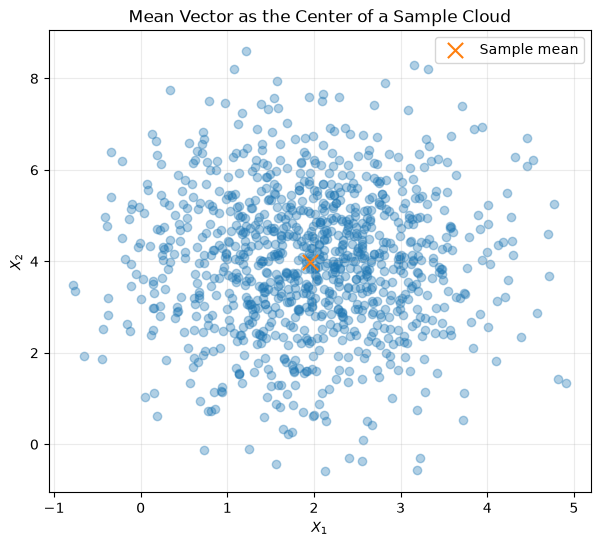

In [3]:

mean = np.array([2.0, 4.0])

samples = rng.normal(loc=mean, scale=[1.0, 1.5], size=(1000, 2))

sample_mean = samples.mean(axis=0)

print("Specified mean:", mean)
print("Estimated sample mean:", sample_mean)

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.35)
plt.scatter(sample_mean[0], sample_mean[1], marker="x", s=120, label="Sample mean")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Mean Vector as the Center of a Sample Cloud")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


The estimated sample mean will not exactly equal the specified mean because we only drew a finite number of samples.

As the number of samples increases, the estimate tends to approach the true mean.

## 4. Variance and Covariance

Variance describes how much a variable varies around its mean:

$$\operatorname{Var}(X)=
\mathbb{E}\left[(X-\mu_X)^2\right]
$$

Covariance extends this idea to **two variables**:

$$\operatorname{Cov}(X,Y)=
\mathbb{E}
\left[
(X-\mu_X)(Y-\mu_Y)
\right].
$$

The sign of the covariance gives us useful information.

### Positive covariance

If $X$ is above its mean, $Y$ also tends to be above its mean.

### Negative covariance

If $X$ is above its mean, $Y$ tends to be below its mean.

### Covariance near zero

There is little or no **linear** relationship between their deviations.

Important:

> Zero covariance does not always imply independence.

For jointly Gaussian variables, however, zero covariance does imply independence.

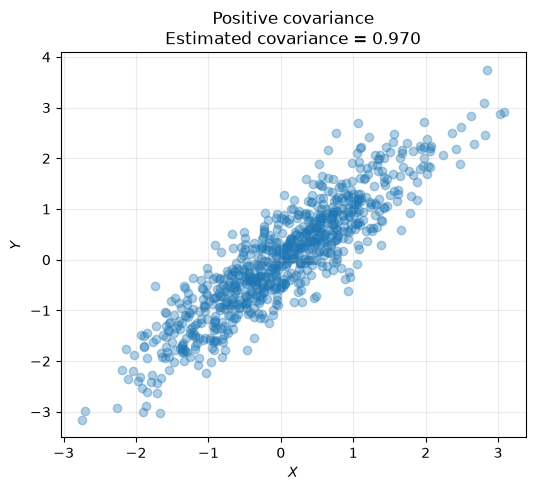

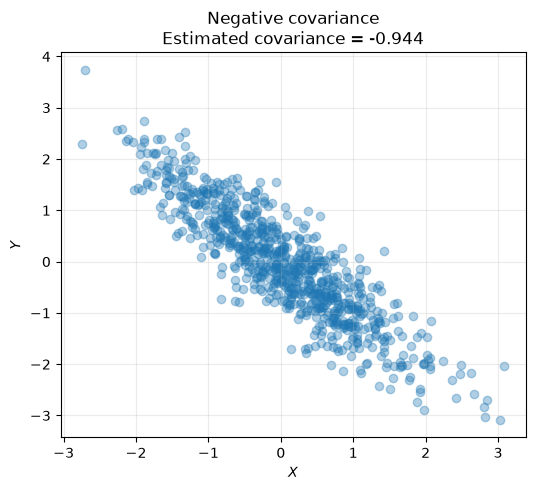

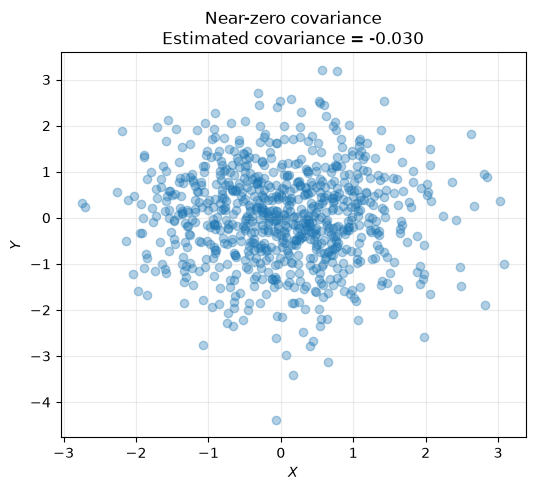

In [4]:

n = 800

x = rng.normal(size=n)

positive_y = x + rng.normal(scale=0.5, size=n)
negative_y = -x + rng.normal(scale=0.5, size=n)
uncorrelated_y = rng.normal(size=n)

datasets = {
    "Positive covariance": positive_y,
    "Negative covariance": negative_y,
    "Near-zero covariance": uncorrelated_y,
}

for title, y in datasets.items():
    cov = np.cov(x, y, ddof=1)[0, 1]

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.35)
    plt.xlabel("$X$")
    plt.ylabel("$Y$")
    plt.title(f"{title}\nEstimated covariance = {cov:.3f}")
    plt.grid(alpha=0.25)
    plt.show()



## 5. Covariance Matrix

For a random vector

$$\mathbf{X}=
\begin{bmatrix}
X_1\\
X_2
\end{bmatrix},
$$

the covariance matrix is

$$\Sigma=
\begin{bmatrix}
\operatorname{Var}(X_1) &
\operatorname{Cov}(X_1,X_2)
\\
\operatorname{Cov}(X_2,X_1) &
\operatorname{Var}(X_2)
\end{bmatrix}.
$$

Because

$$\operatorname{Cov}(X_1,X_2)=
\operatorname{Cov}(X_2,X_1),
$$

the covariance matrix is always symmetric.

The diagonal entries contain the individual variances.

The off-diagonal entries describe how pairs of variables vary together.


In [5]:

samples = np.column_stack([x, positive_y])

covariance_matrix = np.cov(samples, rowvar=False, ddof=1)

print("Estimated covariance matrix:")
print(covariance_matrix)

Estimated covariance matrix:
[[0.94  0.97 ]
 [0.97  1.246]]


For $d$ variables, the covariance matrix has shape

$
d \times d.
$

For example, a vehicle state

$$\mathbf{x}=
\begin{bmatrix}
x\\
y\\
v_x\\
v_y
\end{bmatrix}
$$

would have a $4\times4$ covariance matrix.

This matrix represents not only the uncertainty of each component, but also the pairwise relationships between them.



## 6. Correlation

Covariance depends on the scale of the variables.

Correlation normalizes covariance:

$$\rho_{XY}=
\frac{\operatorname{Cov}(X,Y)}
{\sigma_X\sigma_Y}.
$$

Therefore,

$
-1 \leq \rho_{XY} \leq 1.
$

Interpretation:

- $\rho \approx 1$: strong positive linear relationship,
- $\rho \approx -1$: strong negative linear relationship,
- $\rho \approx 0$: weak linear relationship.


In [6]:
correlation_matrix = np.corrcoef(samples, rowvar=False)

print("Correlation matrix:")
print(correlation_matrix)

Correlation matrix:
[[1.    0.896]
 [0.896 1.   ]]



## 7. Properties of a Covariance Matrix

A valid covariance matrix must be:

1. **square**,
2. **symmetric**,
3. **positive semidefinite**.

Positive semidefinite means:

$$
\mathbf{z}^\top \Sigma \mathbf{z} \geq 0
$$

for every vector $\mathbf{z}$.

Why?

Because $\mathbf{z}^\top\Sigma\mathbf{z}$ can be interpreted as the variance of a linear combination of the random variables, and variance cannot be negative.

A covariance matrix is **positive definite** if

$$
\mathbf{z}^\top \Sigma \mathbf{z} > 0
$$

for every nonzero $\mathbf{z}$.

In [7]:
Sigma = np.array([
    [4.0, 1.5],
    [1.5, 2.0],
])

print("Sigma:")
print(Sigma)

print("\nSymmetric:", np.allclose(Sigma, Sigma.T))

eigenvalues = np.linalg.eigvalsh(Sigma)

print("Eigenvalues:", eigenvalues)
print("Positive definite:", np.all(eigenvalues > 0))

Sigma:
[[4.  1.5]
 [1.5 2. ]]

Symmetric: True
Eigenvalues: [1.197 4.803]
Positive definite: True



## 8. The Multivariate Gaussian Distribution

A $d$-dimensional Gaussian distribution is written as

$$
\mathbf{X}
\sim
\mathcal{N}(\boldsymbol{\mu}, \Sigma).
$$

Its probability density function is

$$p(\mathbf{x})=
\frac{1}
{\sqrt{(2\pi)^d |\Sigma|}}
\exp
\left(
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
\right).
$$

Let's interpret the major pieces.

### $\boldsymbol{\mu}$

Determines the center of the distribution.

### $\Sigma$

Controls:

- spread,
- orientation,
- correlation between variables.

### $|\Sigma|$

The determinant influences the volume occupied by the distribution.

### $\Sigma^{-1}$

The inverse covariance matrix is also called the **precision matrix**.

The quadratic term

$$
(\mathbf{x}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
$$

is the squared **Mahalanobis distance** from $\mathbf{x}$ to the mean.


In [9]:

def multivariate_gaussian_pdf(
    x: np.ndarray,
    mean: np.ndarray,
    covariance: np.ndarray,
) -> float:
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    covariance = np.asarray(covariance, dtype=float)

    d = mean.size

    if x.shape != mean.shape:
        raise ValueError("x and mean must have the same shape.")

    if covariance.shape != (d, d):
        raise ValueError("covariance must have shape (d, d).")

    sign, logdet = np.linalg.slogdet(covariance)

    if sign <= 0:
        raise ValueError(
            "covariance must be positive definite."
        )

    difference = x - mean

    mahalanobis_squared = difference @ np.linalg.solve(
        covariance,
        difference,
    )

    log_normalizer = -0.5 * (
        d * np.log(2.0 * np.pi) + logdet
    )

    log_density = log_normalizer - 0.5 * mahalanobis_squared

    return float(np.exp(log_density))


In [12]:

mean = np.array([0.0, 0.0])

Sigma = np.array([
    [2.0, 1.2],
    [1.2, 1.5],
])

points = [
    np.array([0.0, 0.0]),
    np.array([1.0, 2.0]),
    np.array([3.0, 3.0]),
]

for point in points:
    density = multivariate_gaussian_pdf(
        point,
        mean,
        Sigma,
    )
    print(f"p({point}) = {density:.6f}")


p([0. 0.]) = 0.127426
p([1. 2.]) = 0.028251
p([3. 3.]) = 0.005336



The density is highest close to the mean and becomes smaller as we move farther away.

Because covariance determines the geometry of the distribution, two points with the same Euclidean distance from the mean can have different Gaussian densities.



## 9. Geometry of the Covariance Matrix

The covariance matrix determines the shape and orientation of the Gaussian.

Consider

$$\Sigma=
Q \Lambda Q^\top
$$

where:

- columns of $Q$ are eigenvectors,
- diagonal entries of $\Lambda$ are eigenvalues.

The eigenvectors give the **principal directions** of the Gaussian.

The eigenvalues give the amount of variance along those directions.

For a two-dimensional Gaussian, equal-density contours form ellipses.


Eigenvalues:
[0.438 4.562]

Eigenvectors:
[[ 0.615 -0.788]
 [-0.788 -0.615]]


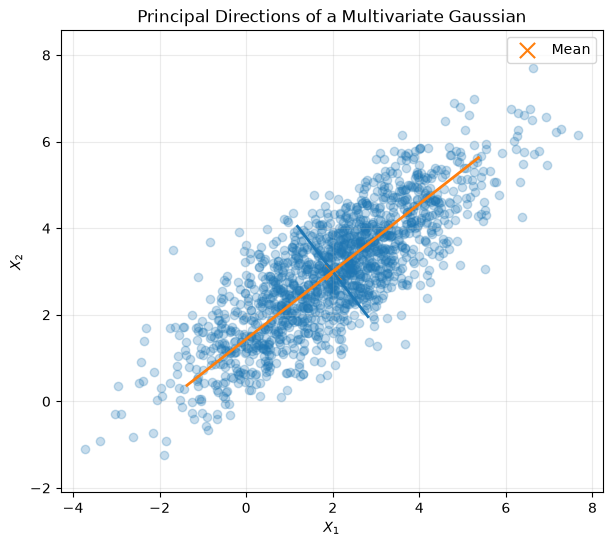

In [13]:

mean = np.array([2.0, 3.0])

Sigma = np.array([
    [3.0, 2.0],
    [2.0, 2.0],
])

samples = rng.multivariate_normal(
    mean=mean,
    cov=Sigma,
    size=1500,
)

eigenvalues, eigenvectors = np.linalg.eigh(Sigma)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.25)
plt.scatter(mean[0], mean[1], marker="x", s=120, label="Mean")

for value, vector in zip(eigenvalues, eigenvectors.T):
    direction = vector * np.sqrt(value) * 2.0

    plt.plot(
        [mean[0] - direction[0], mean[0] + direction[0]],
        [mean[1] - direction[1], mean[1] + direction[1]],
        linewidth=2,
    )

plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Principal Directions of a Multivariate Gaussian")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()



## 10. Covariance Ellipse

A covariance ellipse gives a geometric picture of uncertainty.

For the Gaussian,

$$(\mathbf{x}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
=c^2
$$

describes an ellipse in two dimensions.

Its:

- orientation comes from the eigenvectors,
- axis lengths depend on the square roots of the eigenvalues.


In [14]:

def covariance_ellipse_points(
    mean: np.ndarray,
    covariance: np.ndarray,
    scale: float = 1.0,
    num_points: int = 300,
) -> np.ndarray:
    mean = np.asarray(mean, dtype=float)
    covariance = np.asarray(covariance, dtype=float)

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    if np.any(eigenvalues < 0):
        raise ValueError(
            "covariance must be positive semidefinite."
        )

    angles = np.linspace(
        0.0,
        2.0 * np.pi,
        num_points,
    )

    unit_circle = np.vstack([
        np.cos(angles),
        np.sin(angles),
    ])

    scaling = np.diag(np.sqrt(eigenvalues))

    ellipse = (
        mean[:, None]
        + scale * eigenvectors @ scaling @ unit_circle
    )

    return ellipse.T


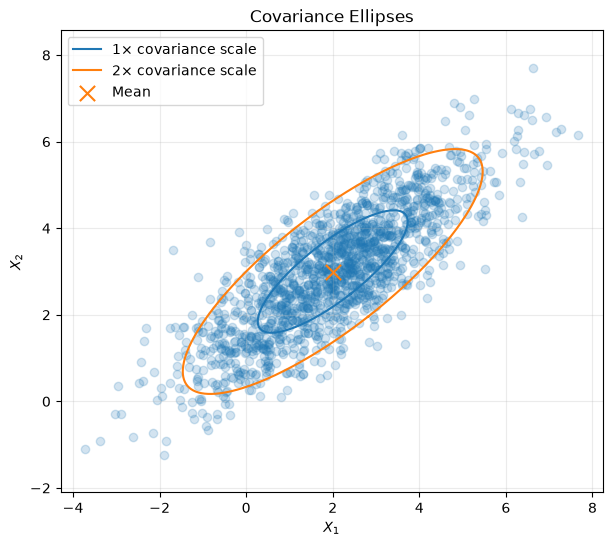

In [15]:

ellipse_1 = covariance_ellipse_points(
    mean,
    Sigma,
    scale=1.0,
)

ellipse_2 = covariance_ellipse_points(
    mean,
    Sigma,
    scale=2.0,
)

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.2)
plt.plot(ellipse_1[:, 0], ellipse_1[:, 1], label="1× covariance scale")
plt.plot(ellipse_2[:, 0], ellipse_2[:, 1], label="2× covariance scale")
plt.scatter(mean[0], mean[1], marker="x", s=120, label="Mean")

plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Covariance Ellipses")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()



## 11. Independent vs Correlated Gaussian Variables

Suppose

$$\Sigma
=\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix}.
$$

The variables are uncorrelated and, because the joint distribution is Gaussian, independent.

Now consider

$$\Sigma=
\begin{bmatrix}
1 & 0.8\\
0.8 & 1
\end{bmatrix}.
$$

The off-diagonal covariance creates a tilted probability cloud.


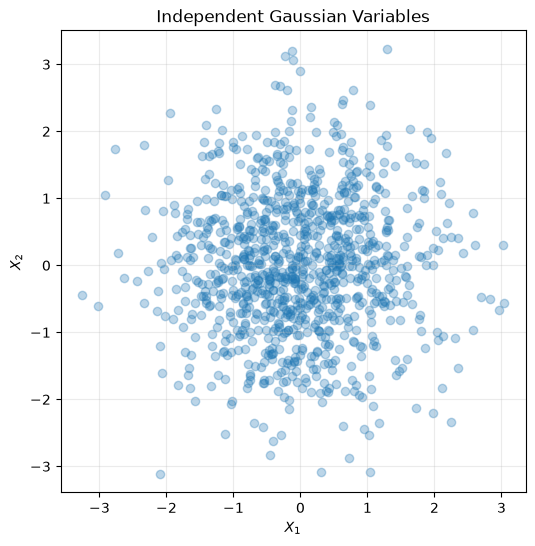

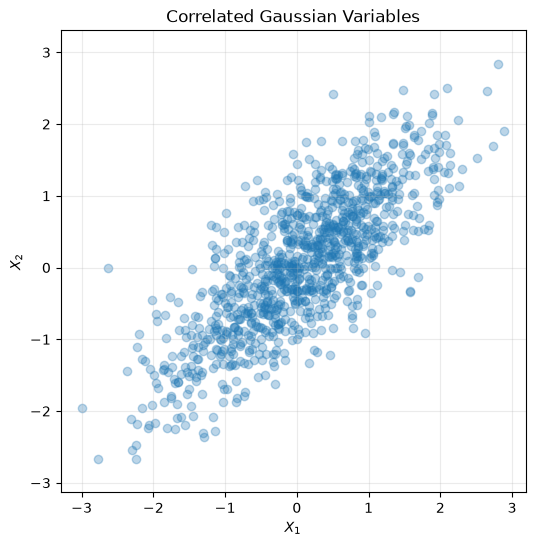

In [16]:

mean = np.array([0.0, 0.0])

independent_covariance = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
])

correlated_covariance = np.array([
    [1.0, 0.8],
    [0.8, 1.0],
])

independent_samples = rng.multivariate_normal(
    mean,
    independent_covariance,
    size=1000,
)

correlated_samples = rng.multivariate_normal(
    mean,
    correlated_covariance,
    size=1000,
)

for title, data in [
    ("Independent Gaussian Variables", independent_samples),
    ("Correlated Gaussian Variables", correlated_samples),
]:
    plt.figure(figsize=(6, 6))
    plt.scatter(data[:, 0], data[:, 1], alpha=0.3)
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.title(title)
    plt.axis("equal")
    plt.grid(alpha=0.25)
    plt.show()



## 12. Sampling from a Multivariate Gaussian

NumPy can directly generate samples:

```python
rng.multivariate_normal(mean, covariance, size=n)
```

But it is useful to understand what happens underneath.

Suppose

$$
\mathbf{z}
\sim
\mathcal{N}(\mathbf{0}, I).
$$

These are independent standard Gaussian variables.

If we find a matrix $L$ such that

$$
\Sigma = LL^\top,
$$

then

$$\mathbf{x}=
\boldsymbol{\mu}
+
L\mathbf{z}
$$

has distribution

$$
\mathbf{x}
\sim
\mathcal{N}(\boldsymbol{\mu},\Sigma).
$$

One common way to obtain $L$ is the **Cholesky decomposition**.


In [17]:

def sample_multivariate_gaussian(
    mean: np.ndarray,
    covariance: np.ndarray,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    mean = np.asarray(mean, dtype=float)
    covariance = np.asarray(covariance, dtype=float)

    if rng is None:
        rng = np.random.default_rng()

    d = mean.size

    if covariance.shape != (d, d):
        raise ValueError(
            "covariance must have shape (d, d)."
        )

    if not np.allclose(covariance, covariance.T):
        raise ValueError(
            "covariance must be symmetric."
        )

    L = np.linalg.cholesky(covariance)

    z = rng.standard_normal(
        size=(n_samples, d),
    )

    samples = mean + z @ L.T

    return samples


In [18]:

mean = np.array([3.0, -1.0])

Sigma = np.array([
    [2.0, 1.0],
    [1.0, 1.5],
])

manual_samples = sample_multivariate_gaussian(
    mean,
    Sigma,
    n_samples=100_000,
    rng=rng,
)

estimated_mean = manual_samples.mean(axis=0)
estimated_covariance = np.cov(
    manual_samples,
    rowvar=False,
    ddof=1,
)

print("Target mean:")
print(mean)

print("\nEstimated mean:")
print(estimated_mean)

print("\nTarget covariance:")
print(Sigma)

print("\nEstimated covariance:")
print(estimated_covariance)


Target mean:
[ 3. -1.]

Estimated mean:
[ 2.998 -0.999]

Target covariance:
[[2.  1. ]
 [1.  1.5]]

Estimated covariance:
[[1.997 0.994]
 [0.994 1.504]]



The empirical mean and covariance should be close to the values we specified.

This experiment demonstrates an important idea:

> Correlated Gaussian samples can be generated by transforming independent standard Gaussian samples.


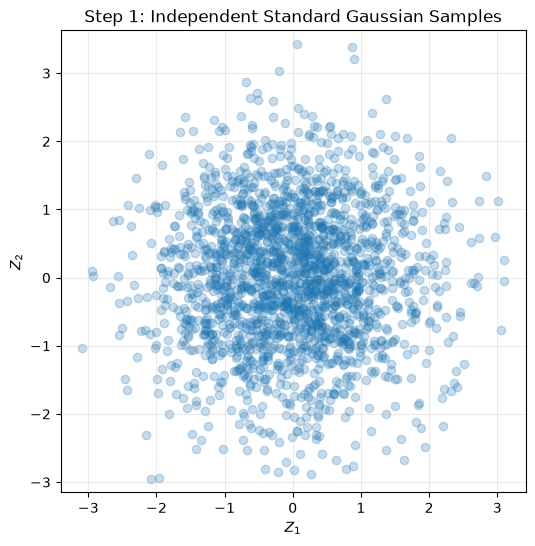

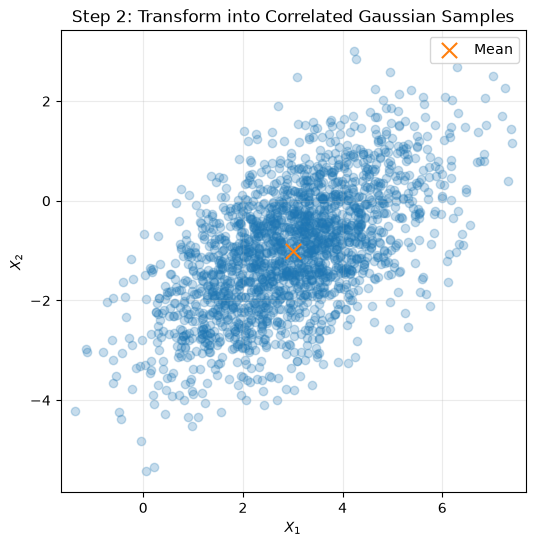

In [19]:

standard_samples = rng.standard_normal(
    size=(2000, 2),
)

L = np.linalg.cholesky(Sigma)

transformed_samples = mean + standard_samples @ L.T

plt.figure(figsize=(6, 6))
plt.scatter(
    standard_samples[:, 0],
    standard_samples[:, 1],
    alpha=0.25,
)
plt.xlabel("$Z_1$")
plt.ylabel("$Z_2$")
plt.title("Step 1: Independent Standard Gaussian Samples")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    transformed_samples[:, 0],
    transformed_samples[:, 1],
    alpha=0.25,
)
plt.scatter(mean[0], mean[1], marker="x", s=120, label="Mean")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Step 2: Transform into Correlated Gaussian Samples")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()



## 13. Why the Cholesky Transformation Works

Let

$$\mathbf{x}=
\boldsymbol{\mu}+L\mathbf{z},
$$

where

$$
\mathbf{z}
\sim
\mathcal{N}(\mathbf{0},I).
$$

The mean is

$$\mathbb{E}[\mathbf{x}]=
\boldsymbol{\mu}
+
L\mathbb{E}[\mathbf{z}]=
\boldsymbol{\mu}.
$$

The covariance is

$$\operatorname{Cov}(\mathbf{x})=
L
\operatorname{Cov}(\mathbf{z})
L^\top.
$$

Because

$$
\operatorname{Cov}(\mathbf{z})=I,
$$

we obtain

$$\operatorname{Cov}(\mathbf{x})=
LIL^\top=
LL^\top=
\Sigma.
$$

Therefore the transformation produces exactly the desired mean and covariance.



## 14. Mahalanobis Distance

Euclidean distance treats all directions equally.

For a Gaussian distribution, however, uncertainty may be much larger in one direction than another.

The Mahalanobis distance accounts for covariance:

$$d_M(\mathbf{x})=
\sqrt{
(\mathbf{x}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\mathbf{x}-\boldsymbol{\mu})
}.
$$

A displacement along a high-variance direction is considered less surprising than the same Euclidean displacement along a low-variance direction.


In [20]:

def mahalanobis_distance(
    x: np.ndarray,
    mean: np.ndarray,
    covariance: np.ndarray,
) -> float:
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    covariance = np.asarray(covariance, dtype=float)

    difference = x - mean

    squared_distance = difference @ np.linalg.solve(
        covariance,
        difference,
    )

    return float(np.sqrt(squared_distance))


In [21]:

mean = np.array([0.0, 0.0])

Sigma = np.array([
    [4.0, 0.0],
    [0.0, 0.25],
])

point_a = np.array([2.0, 0.0])
point_b = np.array([0.0, 2.0])

for point in [point_a, point_b]:
    euclidean = np.linalg.norm(point - mean)
    mahalanobis = mahalanobis_distance(
        point,
        mean,
        Sigma,
    )

    print(
        f"{point}: "
        f"Euclidean = {euclidean:.3f}, "
        f"Mahalanobis = {mahalanobis:.3f}"
    )


[2. 0.]: Euclidean = 2.000, Mahalanobis = 1.000
[0. 2.]: Euclidean = 2.000, Mahalanobis = 4.000



Both points are equally far away according to Euclidean distance.

But because the Gaussian has much more uncertainty in the $x$-direction than in the $y$-direction, the second point is much more unusual according to the model.

This idea is important in anomaly detection, state estimation, data association, and probabilistic robotics.



## 15. A Small Robotics Example

Suppose a localization system estimates the position of a robot as

$$\boldsymbol{\mu}=
\begin{bmatrix}
10\\
5
\end{bmatrix}
$$

with covariance

$$\Sigma=
\begin{bmatrix}
4 & 1.5\\
1.5 & 1
\end{bmatrix}.
$$

The mean gives the most likely location.

The covariance tells us how uncertain the estimate is and how the $x$- and $y$-errors are related.


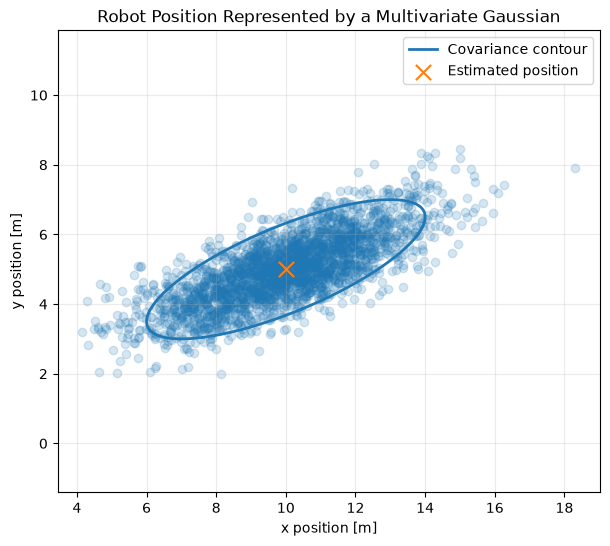

In [22]:

robot_mean = np.array([10.0, 5.0])

robot_covariance = np.array([
    [4.0, 1.5],
    [1.5, 1.0],
])

robot_samples = rng.multivariate_normal(
    robot_mean,
    robot_covariance,
    size=2500,
)

ellipse = covariance_ellipse_points(
    robot_mean,
    robot_covariance,
    scale=2.0,
)

plt.figure(figsize=(7, 6))
plt.scatter(
    robot_samples[:, 0],
    robot_samples[:, 1],
    alpha=0.18,
)
plt.plot(
    ellipse[:, 0],
    ellipse[:, 1],
    linewidth=2,
    label="Covariance contour",
)
plt.scatter(
    robot_mean[0],
    robot_mean[1],
    marker="x",
    s=120,
    label="Estimated position",
)

plt.xlabel("x position [m]")
plt.ylabel("y position [m]")
plt.title("Robot Position Represented by a Multivariate Gaussian")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


The Gaussian representation gives us much more information than a single coordinate.

Instead of saying:

> The robot is at $(10,5)$.

we are saying:

> The robot's position is uncertain, and our belief about that uncertainty is represented by a probability distribution centered at $(10,5)$.

This distinction becomes central when we perform state estimation and inference.


## 16. Summary

A multivariate Gaussian is represented as

$$
\mathbf{X}
\sim
\mathcal{N}
(
\boldsymbol{\mu},
\Sigma
).
$$

The **mean vector**

$$
\boldsymbol{\mu}
$$

describes the center of the distribution.

The **covariance matrix**

$$
\Sigma
$$

describes:

- variance of each variable,
- covariance between variables,
- shape of the probability cloud,
- orientation of the distribution.

Its diagonal entries are variances:

$$\Sigma_{ii}=
\operatorname{Var}(X_i).
$$

Its off-diagonal entries are covariances:

$$\Sigma_{ij}=
\operatorname{Cov}(X_i,X_j).
$$

The eigenvectors of \(\Sigma\) determine the principal directions of the Gaussian, while the eigenvalues determine the spread along those directions.

Correlated samples can be generated using

$$\mathbf{x}=
\boldsymbol{\mu}
+
L\mathbf{z},
$$

where

$$
LL^\top=\Sigma
$$

and

$$
\mathbf{z}
\sim
\mathcal{N}(\mathbf{0},I).
$$

---

## Next Step

We now have the representation required for **Inference in Gaussian Models**.

The next conceptual step is to understand operations on Gaussian distributions, especially:

- marginalization,
- conditioning,
- products of Gaussians.

These operations will play a role similar to the factor operations used for discrete probabilistic models.
